<a href="https://colab.research.google.com/github/rameshaditya-me/Easy-Classical-ML-DL/blob/main/regularized-regression/regression_regularized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularized Linear Regression
---

# Regularized Linear Regression
---

This notebook covers three regularized linear models:

1. **Ridge** ($L_2$ penalty)
2. **Lasso** ($L_1$ penalty)
3. **Elastic Net** ($L_1 + L_2$)

Regularization can be understood in two equivalent ways:

### Bias–variance tradeoff

Unpenalized OLS can overfit when features are many or collinear. Adding a penalty **shrinks** the weights, which **increases bias** but often **reduces variance** and improves test error.

### Prior on the weights

In a Bayesian view, the penalty corresponds to a **prior** on $W$:

- Ridge → Gaussian prior on $W$
- Lasso → Laplace prior on $W$

Maximizing the **posterior** (MAP) is the same as minimizing **loss + regularization** in the frequentist picture.

These are two descriptions of the same idea: constrain $W$ so the model generalizes better.

### Setup
---
The basic linear regression model is that given a dataset $\mathcal{D}=(X,Y)$ where $X\in\mathbb{R}^{n\times d+1}$ and $Y\in\mathbb{R}^{n\times m}$. The goal is to use a linear model $W\in\mathbb{R}^{d+1 \times m}$ and predict the targets $Y$ as $Y=XW$.

The weights are chosen using the objective
$$
\hat{W} = \underset{W}{\operatorname{argmax}} ||Y-XW||_2^2
$$

### Ridge Regression
---
In the ridge regression model we assume a different objective function which is defined as
$$
\hat{W} = \underset{W}{\operatorname{argmax}} ||Y-XW||_2^2 + \lambda ||W||_2^2
$$

Where, $\lambda$ is a regularization parameter and $||W||_2^2$ represents the $L_2$ norm of the weights.

In a ridge regression model we penalize large values of slope and prefer smaller values of slope which minimizes the sum of squared residual errors.

### LASSO Regression
---
In the LASSO regression model we assume a different objective function which is defined as
$$
\hat{W} = \underset{W}{\operatorname{argmax}} ||Y-XW||_2^2 + \lambda ||W||_1
$$

Where, $\lambda$ is a regularization parameter and $||W||_1$ represents the $L_1$ norm of the weights.

In a LASSO regression model we penalize large values of slope and prefer smaller values of slope which minimizes the sum of squared residual errors.

### Elastic Net Regression
---
In the Elastic Net regression model we create a hybrid objective which incorporates both the Ridge and LASSO regression penalty. This objective is defined as

$$
\hat{W} = \underset{W}{\operatorname{argmax}} ||Y-XW||_2^2 + \lambda_1 ||W||_1 + \lambda_2 ||W||_2^2
$$

Here $\lambda_1$ and $\lambda_2$ represent the contributions of the Ridge and LASSO penalty to the objective function.

### Questions

**1. What is the difference between the Ridge and LASSO penalties? Both seem to penalize large slopes.**

Ridge and LASSO use the same squared-error loss but encode different assumptions about the weights. Ridge corresponds to a **Gaussian prior** on $W$, which shrinks coefficients smoothly toward zero. LASSO corresponds to a **Laplace prior**, which also shrinks coefficients but can set some of them exactly to zero, yielding sparse models.

**2. Why do we need regularization at all? Why isn’t plain OLS enough?**

To estimate $d$ slopes plus an intercept, you ideally need at least $n \geq d + 1$ samples. OLS has a unique solution only when that condition holds and $X$ is full rank. When $n < d$, or when predictors are redundant or nearly collinear, OLS becomes unstable or ill-defined.

In practice, data are often scarce and features overlap in what they explain. Unregularized OLS can then fit noise in the training set, giving high variance and weak test performance. Regularization penalizes large weights, down-weighting unhelpful features and often improving generalization.

Regularization also makes predictions less sensitive to small changes in the estimated weights, which **reduces variance** at the cost of some **bias**.

To illustrate these ideas, we next work through a small synthetic regression example.

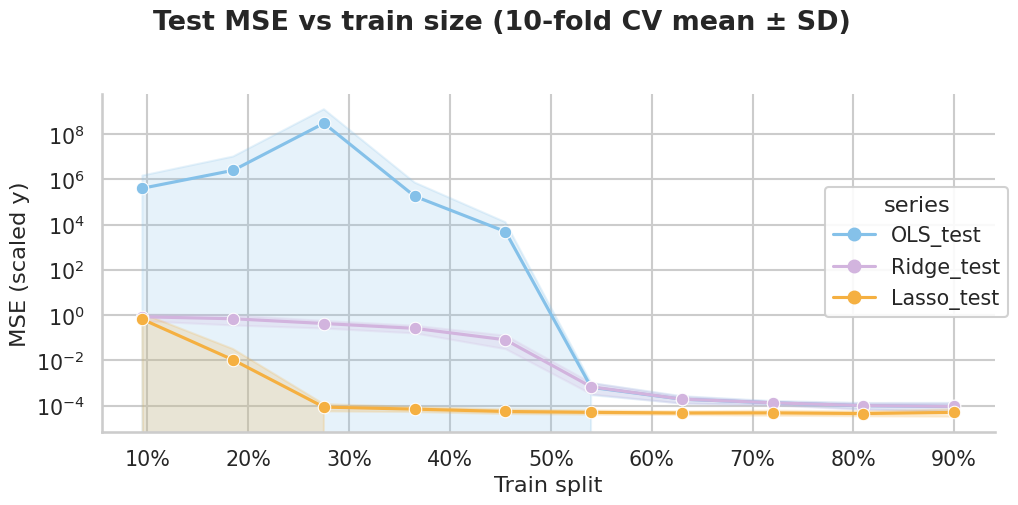

In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.datasets import make_regression
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# --- hard regime: n << p ---
n_samples = 200
n_informative = 10
n_features = 100
noise = 1.0
n_cv_folds = 10

X, y, trueW = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    noise=noise,
    random_state=42,
    coef=True,
)

train_sizes = np.unique(
    (n_samples * (1 - np.linspace(0.1, 0.9, 10))).astype(int)
)

rows = []
for n_train in train_sizes:
    n_test = n_samples - n_train
    cv = ShuffleSplit(
        n_splits=n_cv_folds,
        train_size=n_train,
        test_size=n_test,
        random_state=42,
    )

    for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        x_scaler = StandardScaler().fit(X_tr)
        y_scaler = StandardScaler().fit(y_tr.reshape(-1, 1))

        X_tr_s = x_scaler.transform(X_tr)
        X_te_s = x_scaler.transform(X_te)
        y_tr_s = y_scaler.transform(y_tr.reshape(-1, 1)).ravel()
        y_te_s = y_scaler.transform(y_te.reshape(-1, 1)).ravel()

        X_tr_aug = np.hstack([X_tr_s, np.ones((X_tr_s.shape[0], 1))])
        X_te_aug = np.hstack([X_te_s, np.ones((X_te_s.shape[0], 1))])

        W_ols = np.linalg.inv(X_tr_aug.T @ X_tr_aug) @ X_tr_aug.T @ y_tr_s.reshape(-1, 1)
        ridge = RidgeCV(alphas=np.logspace(-2, 3, 30), fit_intercept=False).fit(X_tr_aug, y_tr_s)
        lasso = LassoCV(alphas=np.logspace(-3, 1, 30), fit_intercept=False, max_iter=20_000).fit(X_tr_aug, y_tr_s)

        rows += [
            {"n_train": n_train, "train_frac": n_train / n_samples, "fold": fold_idx, "series": "OLS_test", "mse": mse(y_te_s, (X_te_aug @ W_ols).ravel())},
            {"n_train": n_train, "train_frac": n_train / n_samples, "fold": fold_idx, "series": "Ridge_test", "mse": mse(y_te_s, ridge.predict(X_te_aug))},
            {"n_train": n_train, "train_frac": n_train / n_samples, "fold": fold_idx, "series": "Lasso_test", "mse": mse(y_te_s, lasso.predict(X_te_aug))},
        ]

df = pd.DataFrame(rows)

order = ["OLS_test", "Ridge_test", "Lasso_test"]
palette = {
    "OLS_test": "#85c1e9",
    "Ridge_test": "#d2b4de",
    "Lasso_test": "#f5b041",
}

sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)
g = sns.relplot(
    data=df, x="train_frac", y="mse", hue="series",
    hue_order=order, palette=palette,
    kind="line", marker="o", errorbar="sd",
    height=5, aspect=1.7,
)
g.set_axis_labels("Train split", "MSE (scaled y)")
g.ax.xaxis.set_major_formatter(PercentFormatter(1.0))
g.ax.set_yscale("log")
g.fig.suptitle(
    f"Test MSE vs train size ({n_cv_folds}-fold CV mean ± SD)",
    y=1.02, weight="semibold",
)
sns.move_legend(g, "center right", frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

In the above plot we use a synthetic example to generate an example to illustrate the conditions under which regularization is important. As discussed previously, the OLS soln is not robust when a) The features are correlated OR in other words redundant b) The matrix $X^TX$ is rank deficient $\rightarrow$ $n\leq d$.

We simulate this by using the "make_regression" function and keeping the total features $d=100$ with the actual informative features as $10$. We further sweep the train test split from $10\%$ to $90\%$ and analyze the quality of the fit for OLS, Ridge and LASSO regression models.

The MSE is plotted along with the STD with $10$ fold cross-validation. As can be inferred from the plot, For train-split $< 50\%$ the MSE of the OLS regression blows up significantly compared to Ridge and LASSO regression objectives. As the train-split increases more than $50\%$ the MSE converges for the 3 models.